# Fast and Accurate SABR Calibration for AAPL Options: A Hybrid Optimization Approach

## 1. Environment Setup

This notebook studies the calibration of the **SABR (Stochastic Alpha, Beta, Rho)** model to **AAPL option implied volatilities**. The goal is to compare how different optimization methods perform when fitting a parametric volatility model to observed market data.

The notebook uses live option chain data from **Yahoo Finance**, computes implied volatilities from observed option mid-prices, and then fits the SABR model using three calibration approaches:

- **L-BFGS-B** — a fast local optimizer
- **Differential Evolution** — a global optimization method
- **Hybrid Differential Evolution → L-BFGS-B** — a two-stage method combining global search with local refinement

The analysis focuses on both:

- **Calibration accuracy**, measured using **RMSE**
- **Calibration speed**, measured using runtime in seconds

In addition to reporting the best-fitting parameters, the notebook visualizes:

- residual errors across strikes,
- fitted volatility smiles for each optimization method,
- the trade-off between runtime and fit quality,
- and a 3D comparison of market versus model-implied volatilities across strikes and expiries.

This project is useful for understanding how optimizer choice affects practical volatility model calibration in quantitative finance.

In [35]:
#Title: Fast and Accurate SABR Calibration for AAPL Options: A Hybrid Optimization Approach

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
import yfinance as yf
from scipy.optimize import minimize, differential_evolution, brentq
from scipy.stats import norm

## 2. Black–Scholes Pricing and Implied Volatility

Before calibrating SABR, we first need a way to convert observed option prices into **implied volatilities**. This section defines two helper functions:

1. A **Black–Scholes pricing function** for calls and puts
2. An **implied volatility solver** using **Brent’s root-finding method**

The pricing function takes the spot/forward level, strike, maturity, and volatility as inputs and returns the theoretical option price.  
The implied volatility solver then numerically inverts this pricing relationship: given a market option price, it finds the volatility that reproduces that price.

This step is important because SABR is calibrated to the **implied volatility smile**, not directly to raw option prices.

In [36]:
#Black-Scholes and implied volatility
def bsp(F, K, T, sigma, option_type="C"):
    if sigma <= 0 or T <= 0:
        return np.nan
    d1 = (np.log(F/K) + 0.5*sigma**2*T) / (sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)
    if option_type == "C":
        return F * norm.cdf(d1) - K * norm.cdf(d2)
    else:
        return K * norm.cdf(-d2) - F * norm.cdf(-d1)

def impvol(F, K, T, price, option_type="C"):
    if price <= 0 or T <= 0 or F <= 0 or K <= 0:
        return np.nan
    try:
        func = lambda s: bsp(F, K, T, s, option_type) - price
        return brentq(func, 1e-6, 5.0)
    except Exception:
        return np.nan

## 3. SABR Model (Hagan 2002 Approximation)

This section implements the **Hagan et al. (2002)** approximation for SABR implied volatility.

The SABR model is widely used in derivatives markets because it can capture key features of observed volatility smiles and skews through four parameters:

- **alpha**: controls the overall volatility level
- **beta**: controls the elasticity of variance with respect to the underlying
- **rho**: correlation between the asset price and volatility processes
- **nu**: volatility of volatility

The Hagan approximation provides a closed-form expression for implied volatility, making calibration computationally practical. This is especially useful when comparing multiple optimization methods in a data-driven setting.

In [37]:
#SABR implied vol (Hagan 2002 approximation)
def sabr_impvol(F, K, T, alpha, beta, rho, nu):
    if F <= 0 or K <= 0 or alpha <= 0 or T <= 0:
        return np.nan
    if F == K:
        term1 = alpha / (F ** (1 - beta))
        term2 = 1 + ((2 - 3 * rho**2) * nu**2 * T) / 24
        return term1 * term2
    logFK = np.log(F / K)
    FK_beta = (F * K) ** ((1 - beta) / 2)
    z = (nu / alpha) * FK_beta * logFK
    xz = np.log((np.sqrt(1 - 2 * rho * z + z ** 2) + z - rho) / (1 - rho))
    A = alpha / (FK_beta * (1 + ((1 - beta)**2 / 24) * logFK**2 + ((1 - beta)**4 / 1920) * logFK**4))
    B = z / xz
    correction = 1 + (((1 - beta)**2 / 24) * (alpha**2 / FK_beta**2) + (rho * beta * nu * alpha) / (4 * FK_beta) + ((2 - 3*rho**2)/24) * nu**2) * T
    return A * B * correction

## 4. RMSE Objective Function

To calibrate SABR, we need an objective function that measures how closely the model matches market data.

Here, the calibration error is defined as the **Root Mean Squared Error (RMSE)** between:

- the **market implied volatilities**, and
- the **SABR model implied volatilities**

Lower RMSE indicates a better fit.

The function also includes parameter validity checks so that invalid parameter combinations are heavily penalized. This helps keep the optimizer inside a sensible region of the SABR parameter space.

In [38]:
#defining the RMSE function 
def sabr_rmse(params, F, K, T, market_vols):
    alpha, beta, rho, nu = params
    if not (0 < beta <= 1) or not (-0.999 < rho < 0.999) or alpha <= 0 or nu <= 0:
        return 1e6
    model_vols = np.array([sabr_impvol(F, k, T, alpha, beta, rho, nu) for k in K])
    mask = np.isfinite(model_vols) & np.isfinite(market_vols)
    if np.sum(mask) < 3:
        return 1e6
    return np.sqrt(np.mean((model_vols[mask] - market_vols[mask])**2))

## 5. Download AAPL Option Data

This section downloads **AAPL option chain data** from Yahoo Finance and prepares it for calibration.

For each available expiry (up to a chosen maximum):

- call option quotes are retrieved,
- mid-prices are computed from bid and ask,
- invalid observations are filtered out,
- and implied volatilities are calculated using the Black–Scholes inversion routine defined earlier.

The result is a clean set of strike/implied-volatility pairs across expiries, which will later be used to calibrate the SABR model.

Only expiries with more than a few days remaining are retained to avoid extremely short-dated contracts that may introduce instability in the implied volatility calculation.

In [39]:
#download AAPL option data
def aapl_option_data(ticker="AAPL", max_expiries=5):
    tk = yf.Ticker(ticker)
    S = tk.history(period="1d")["Close"].iloc[-1]
    expirations = tk.options[:max_expiries]
    today = pd.Timestamp.utcnow().floor('D').tz_localize(None)
    all_data = []
    Ts = []
    for exp in expirations:
        chain = tk.option_chain(exp)
        calls = chain.calls.copy()
        if calls.empty:
            continue
        exp_date = pd.to_datetime(exp).tz_localize(None)
        T_days = max((exp_date - today).days, 0)
        if T_days <= 3:
            continue
        T = T_days / 365.0
        calls["mid"] = (calls["bid"] + calls["ask"]) / 2
        calls = calls[(calls["strike"] > 0) & (calls["mid"] > 0)]
        calls["iv"] = calls.apply(lambda r: impvol(S, r["strike"], T, r["mid"], "C"), axis=1)
        all_data.append(calls[["strike", "iv"]].copy())
        Ts.append(T)
    if len(all_data) == 0:
        raise ValueError("No valid option chain found for AAPL.")
    return S, Ts, all_data

## 6. Calibration Methods

This notebook compares three different optimization approaches for SABR calibration:

### 1. L-BFGS-B
A gradient-based local optimizer with simple bound constraints.  
It is typically very fast, but its performance can depend heavily on the starting guess.

### 2. Differential Evolution
A population-based global optimizer.  
It is generally more robust to local minima, but it is slower because it explores the parameter space more broadly.

### 3. Hybrid Differential Evolution → L-BFGS-B
A two-step method:
- first, Differential Evolution searches globally for a good region,
- then L-BFGS-B refines the solution locally.

This hybrid approach often balances **global robustness** with **local speed and refinement**, making it a strong candidate for practical calibration problems.

In [40]:
#calibration methods
def calibrate_methods(F, K, T, vols):
    results = {}
    bounds = [(0.001, 2.0), (0.0, 1.0), (-0.999, 0.999), (0.001, 5.0)]
    x0 = [1.8, 0.2, 0.9, 0.5]

    #L-BFGS-B
    t0 = time.time()
    res1 = minimize(sabr_rmse, x0, args=(F, K, T, vols), bounds=bounds, method="L-BFGS-B")
    t1 = time.time()
    results["L-BFGS-B"] = (res1.x, res1.fun, t1 - t0)

    #differential evolution
    t0 = time.time()
    res2 = differential_evolution(sabr_rmse, bounds, args=(F, K, T, vols), polish=False, maxiter=200, popsize=150)
    t1 = time.time()
    results["Differential Evolution"] = (res2.x, res2.fun, t1 - t0)

    #hybrid DE → L-BFGS-B
    t0 = time.time()
    res_de = differential_evolution(sabr_rmse, bounds, args=(F, K, T, vols), polish=False, maxiter=150)
    res_lbfgs = minimize(sabr_rmse, res_de.x, args=(F, K, T, vols), bounds=bounds, method="L-BFGS-B")
    t1 = time.time()
    results["Hybrid DE→L-BFGS-B"] = (res_lbfgs.x, res_lbfgs.fun, t1 - t0)
    return results

## 7. SABR Calibration

In this section, the SABR model is calibrated to the **first available option expiry**.

Using a single expiry allows us to focus clearly on the shape of one volatility smile and compare optimization methods on the same fitting problem. The notebook:

- extracts strikes and market implied volatilities,
- runs all three calibration methods,
- reports parameter estimates,
- compares RMSE values,
- and identifies the best-performing method based on the lowest calibration error.

This provides a direct numerical comparison of accuracy and speed across optimizers.

In [41]:
#SABR calibration
S_multi, Ts, all_data = aapl_option_data(max_expiries=5)
S_single, T_single, df_single = S_multi, Ts[0], [all_data[0]]
K = df_single[0]["strike"].values
vols = df_single[0]["iv"].values
print(f"Number of strikes (first expiry): {len(K)}")
results = calibrate_methods(S_single, K, T_single, vols)
print("\n Calibration Results")
for k, (params, err, t) in results.items():
    print(f"{k:25s}  RMSE={err:.5f}  Time={t:.2f}s  Params={np.round(params,4)}")
best_method = min(results.items(), key=lambda x: x[1][1])[0]
best_params = results[best_method][0]
print(f"\nBest method: {best_method}")

Number of strikes (first expiry): 30

 Calibration Results
L-BFGS-B                   RMSE=0.13753  Time=0.02s  Params=[2.000e+00 7.176e-01 4.263e-01 1.000e-03]
Differential Evolution     RMSE=0.07171  Time=2.54s  Params=[ 1.9783  0.6892 -0.4486  4.9998]
Hybrid DE→L-BFGS-B         RMSE=0.07168  Time=0.25s  Params=[ 2.      0.6882 -0.4487  5.    ]

Best method: Hybrid DE→L-BFGS-B


## 8. Residual Analysis

Residual analysis helps diagnose where the calibrated model is fitting well and where it is struggling.

For each strike, the residual is defined as:

**model implied volatility − market implied volatility**

This plot is useful because it reveals whether the model error is:

- randomly scattered around zero,
- systematically biased in certain strike regions,
- or larger in the wings than near the money.

A well-calibrated model should ideally show small and fairly balanced residuals across strikes.

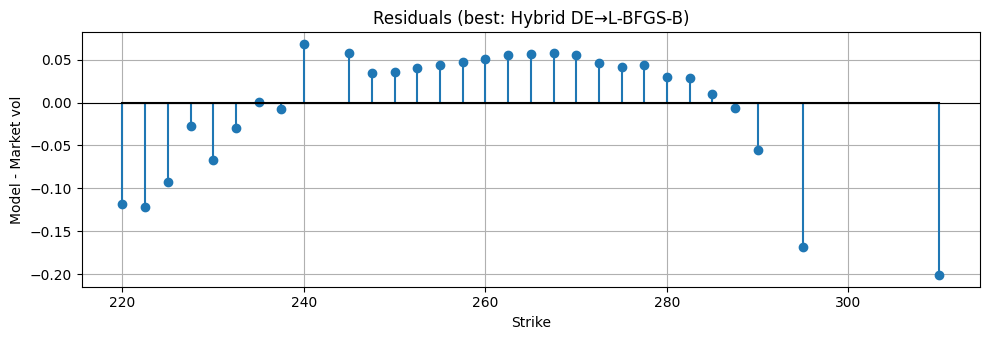

In [42]:
#residuals plot
model_best = [sabr_impvol(S_single, k, T_single, *best_params) for k in K]
resids = np.array(model_best) - np.array(vols)
plt.figure(figsize=(10,3.5))
plt.stem(K, resids, markerfmt="o", basefmt="k-", linefmt="C0-")
plt.axhline(0, color="k", lw=0.8)
plt.title(f"Residuals (best: {best_method})")
plt.xlabel("Strike"); plt.ylabel("Model - Market vol")
plt.grid(True)
plt.tight_layout(); plt.show()

## 9. Model Comparison

This figure compares the observed market implied volatility smile with the SABR smiles produced by each calibration method.

The chart helps answer two practical questions:

- Which optimizer gives the closest overall fit to the market smile?
- How different are the fitted parameterizations produced by local, global, and hybrid methods?

By plotting all fitted curves on the same axes, it becomes easy to visually compare calibration quality across strikes.

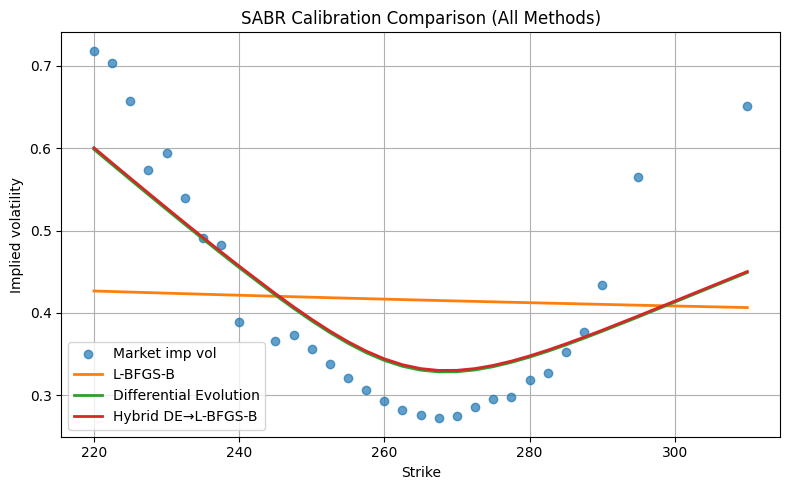

In [43]:
#comparison plot
plt.figure(figsize=(8,5))
plt.plot(K, vols, 'o', label="Market imp vol", alpha=0.7)
for method, (params, _, _) in results.items():
    model_vols = [sabr_impvol(S_single, k, T_single, *params) for k in K]
    plt.plot(K, model_vols, '-', lw=2, label=f"{method}")
plt.xlabel("Strike")
plt.ylabel("Implied volatility")
plt.title("SABR Calibration Comparison (All Methods)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## 10. Speed vs Accuracy

In practical model calibration, the best method is not always the one with the absolute lowest error. Runtime also matters.

This section visualizes the trade-off between:

- **speed** (calibration time in seconds), and
- **accuracy** (RMSE)

A method that is slightly slower but much more accurate may be preferable in research settings, while a faster method may be more useful in production environments where calibrations must be repeated frequently.

The chart below summarizes that trade-off for all three optimizers.

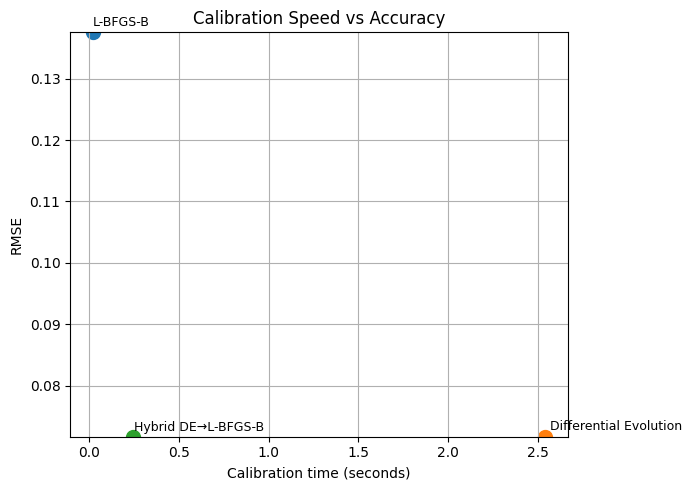

In [44]:
#speed vs accuracy plot
plt.figure(figsize=(7,5))
rmse_vals = [res[1] for res in results.values()]
min_rmse, max_rmse = min(rmse_vals), max(rmse_vals)
y_margin = (max_rmse - min_rmse) * 0.05 if max_rmse > min_rmse else 0.001
for method, (_, rmse, runtime) in results.items():
    plt.scatter(runtime, rmse, s=100, label=method)
    plt.text(runtime*1.01, rmse + y_margin*0.3, method, fontsize=9)
plt.xlabel("Calibration time (seconds)")
plt.ylabel("RMSE")
plt.title("Calibration Speed vs Accuracy")
plt.grid(True)
plt.margins(x=0.05, y=0)
plt.tight_layout()
plt.show()

## 11. 3D Implied Volatility Surface

The final visualization extends the analysis beyond a single expiry and compares **market implied volatilities** with **SABR model implied volatilities** across multiple maturities.

Each point in the 3D plot represents a strike-expiry-volatility observation. Plotting both market and model values together helps assess whether the calibrated SABR parameters capture the broader shape of the implied volatility surface.

This view is especially helpful for identifying:

- maturity-dependent fitting errors,
- surface-level distortions,
- and regions where the model is consistently above or below the market.

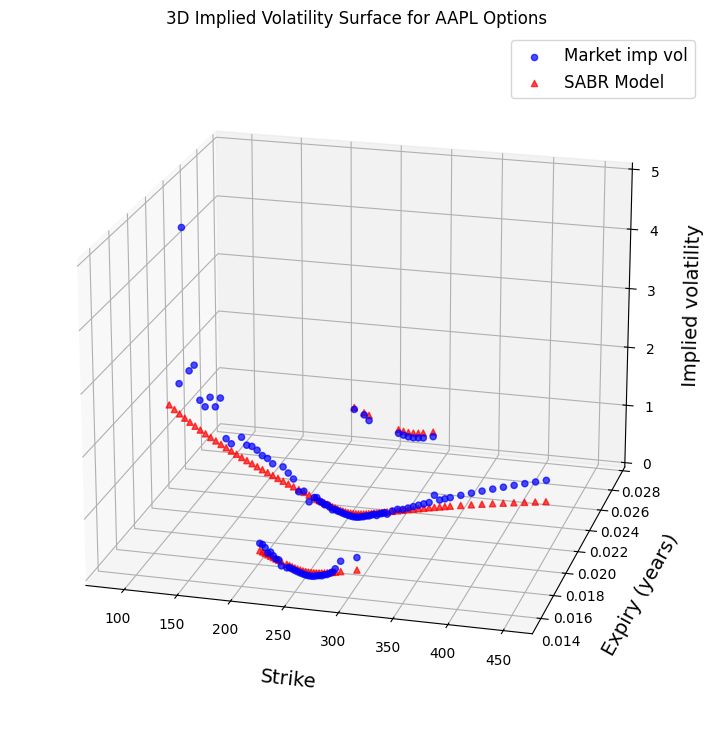

In [45]:
#3D implied volatility surface plot
strikes, expiries, market_vols, model_vols = [], [], [], []
for i, df in enumerate(all_data):
    T = Ts[i]
    for k, iv in zip(df["strike"], df["iv"]):
        strikes.append(k)
        expiries.append(T)
        market_vols.append(iv)
        model_vols.append(sabr_impvol(S_multi, k, T, *best_params))
strikes = np.array(strikes)
expiries = np.array(expiries)
market_vols = np.array(market_vols)
model_vols = np.array(model_vols)
fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(strikes, expiries, market_vols, c='blue', label='Market imp vol', marker='o', alpha=0.7)
ax.scatter(strikes, expiries, model_vols, c='red', label='SABR Model', marker='^', alpha=0.7)
ax.set_xlabel('Strike', fontsize=14, labelpad=15)
ax.set_ylabel('Expiry (years)', fontsize=14, labelpad=15)
ax.set_zlabel('Implied volatility', fontsize=14, labelpad=12, rotation=90)
ax.view_init(elev=20, azim=-75)
ax.legend(fontsize=12)
plt.title("3D Implied Volatility Surface for AAPL Options")
plt.show()